# Motor B — Predicción LightGBM + Explicabilidad SHAP
**TFM: La Dieta de un País · Aguacate Team · Nuclio Digital School**

**Input:** `processed/03_clusters.parquet` (390 × 15)  
**Target (Y):** `CO2eq_t_per_capita` + derivado `CO2eq_per_Kcal`  
**Features (X):** 7 `pct_` + `log_Food_CPI` + `cluster_id`  
**Pipeline:** Regresión Lineal base → LightGBM → SHAP  
**Métricas éxito:** R² ajustado ≥ 0.4 · SHAP signos coherentes con teoría  
**Output:** `processed/04_model_results.parquet`

---
## Celda 1 — Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb
import shap

import gc

# Semilla reproducibilidad
SEED = 42
np.random.seed(SEED)

print('Librerías cargadas correctamente')
print(f'LightGBM version: {lgb.__version__}')
print(f'SHAP version: {shap.__version__}')

Librerías cargadas correctamente
LightGBM version: 4.6.0
SHAP version: 0.51.0


---
## Celda 2 — Carga de datos y validación

In [2]:
df = pd.read_parquet('../processed/03_clusters.parquet')

print(f'Shape: {df.shape}')
print(f'Nulos: {df.isnull().sum().sum()}')
print(f'Países: {df["Area"].nunique()}')
print(f'Años: {sorted(df["Year"].unique())}')
print()
print('Distribución clusters:')
print(df['cluster_nombre'].value_counts())
print()
print('CO2eq_t_per_capita:')
print(df['CO2eq_t_per_capita'].describe().round(3))
print()
print('Food_CPI (raw):')
print(df['Food_CPI'].describe().round(3))

Shape: (390, 15)
Nulos: 0
Países: 30
Años: [np.int16(2010), np.int16(2011), np.int16(2012), np.int16(2013), np.int16(2014), np.int16(2015), np.int16(2016), np.int16(2017), np.int16(2018), np.int16(2019), np.int16(2020), np.int16(2021), np.int16(2022)]

Distribución clusters:
cluster_nombre
Dieta Proteica Diversificada    229
Dieta Cereal-Dependiente        148
Dieta Tuberosa Subsahariana      13
Name: count, dtype: int64

CO2eq_t_per_capita:
count    390.000
mean       2.658
std        2.191
min        0.777
25%        1.259
50%        1.990
75%        2.939
max       12.888
Name: CO2eq_t_per_capita, dtype: float64

Food_CPI (raw):
count     390.000
mean      113.166
std        65.824
min        44.925
25%        94.826
50%       101.610
75%       113.968
max      1076.201
Name: Food_CPI, dtype: float64


---
## Celda 3 — Feature Engineering: log(Food_CPI) + CO2eq_per_Kcal

In [3]:
# Transformación logarítmica del CPI para manejar outlier (max=1076, ~10x precio 2015)
# Documentado en FAQs Q9 — legítimo (probablemente Etiopía o Nigeria en período de crisis)
df['log_Food_CPI'] = np.log(df['Food_CPI'])

# Target derivado: intensidad carbónica por Kcal ingerida
# Permite comparar países con distinto nivel de ingesta total
df['CO2eq_per_Kcal'] = df['CO2eq_t_per_capita'] / (df['Total_DES_Kcal'] * 365 / 1_000_000)
# Unidades: t CO2eq / tonelada-kcal consumida al año

print('Nuevas columnas creadas:')
print(f"log_Food_CPI: media={df['log_Food_CPI'].mean():.3f}, std={df['log_Food_CPI'].std():.3f}")
print(f"  CPI raw max={df['Food_CPI'].max():.1f} → log={df['log_Food_CPI'].max():.3f} (controlado)")
print()
print(f"CO2eq_per_Kcal: media={df['CO2eq_per_Kcal'].mean():.4f}, std={df['CO2eq_per_Kcal'].std():.4f}")

# Verificar no hay NaN ni Inf
assert df['log_Food_CPI'].isnull().sum() == 0
assert df['CO2eq_per_Kcal'].isnull().sum() == 0
assert not np.isinf(df['CO2eq_per_Kcal']).any()
print('\nValidación: sin NaN ni Inf ✅')

Nuevas columnas creadas:
log_Food_CPI: media=4.669, std=0.291
  CPI raw max=1076.2 → log=6.981 (controlado)

CO2eq_per_Kcal: media=2.3097, std=1.7021

Validación: sin NaN ni Inf ✅


---
## Celda 4 — Definición de features y targets

In [4]:
FEATURES = [
    'pct_Cereales',
    'pct_Tuberculos',
    'pct_Azucares',
    'pct_Aceites_Grasas',
    'pct_Carnes',
    'pct_Lacteos_Huevos',
    'pct_Frutas_Verduras',
    'log_Food_CPI',
    'cluster_id'
]

TARGET_ABS  = 'CO2eq_t_per_capita'   # Target principal
TARGET_INT  = 'CO2eq_per_Kcal'       # Target derivado (intensidad)

X = df[FEATURES].copy()
y_abs = df[TARGET_ABS].astype(float)
y_int = df[TARGET_INT].astype(float)

print(f'X shape: {X.shape}')
print(f'Features: {FEATURES}')
print(f'\nY_abs (CO2eq t/cápita): min={y_abs.min():.3f} max={y_abs.max():.3f}')
print(f'Y_int (CO2eq/Kcal):     min={y_int.min():.4f} max={y_int.max():.4f}')
print(f'\nX dtypes:\n{X.dtypes}')

X shape: (390, 9)
Features: ['pct_Cereales', 'pct_Tuberculos', 'pct_Azucares', 'pct_Aceites_Grasas', 'pct_Carnes', 'pct_Lacteos_Huevos', 'pct_Frutas_Verduras', 'log_Food_CPI', 'cluster_id']

Y_abs (CO2eq t/cápita): min=0.777 max=12.888
Y_int (CO2eq/Kcal):     min=0.6867 max=10.1194

X dtypes:
pct_Cereales           float32
pct_Tuberculos         float32
pct_Azucares           float32
pct_Aceites_Grasas     float32
pct_Carnes             float32
pct_Lacteos_Huevos     float32
pct_Frutas_Verduras    float32
log_Food_CPI           float32
cluster_id                int8
dtype: object


---
## Celda 5 — Análisis de correlaciones previo al modelado

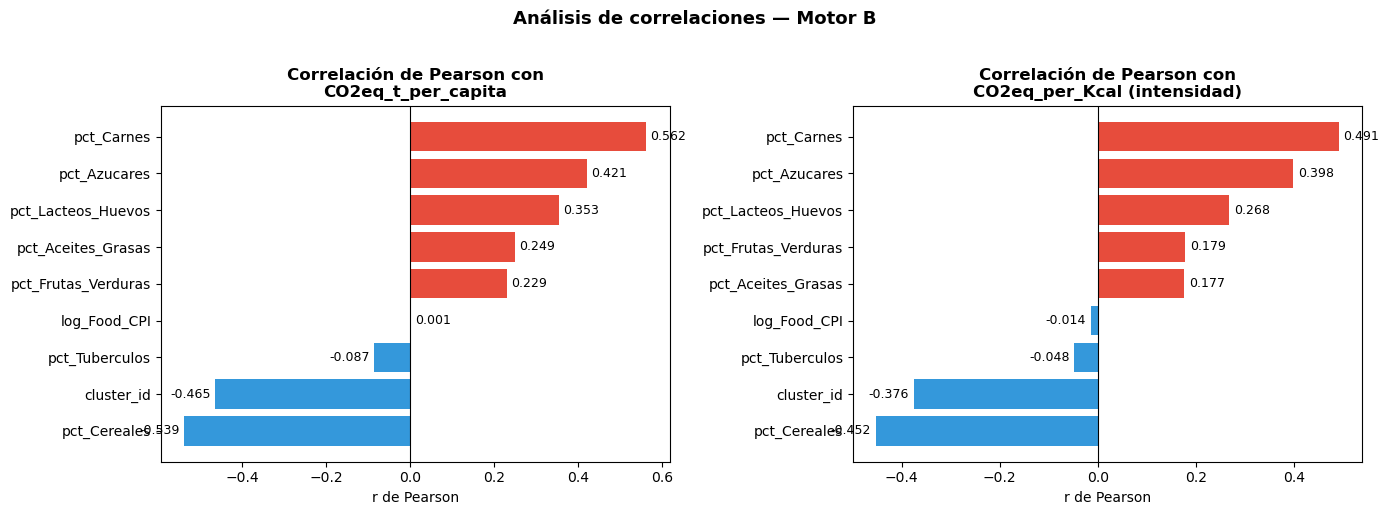

Guardado: processed/04_correlaciones.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlaciones con CO2eq_t_per_capita
corr_abs = X.corrwith(y_abs).sort_values(ascending=True)
colors_abs = ['#e74c3c' if v > 0 else '#3498db' for v in corr_abs]
axes[0].barh(corr_abs.index, corr_abs.values, color=colors_abs)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlación de Pearson con\nCO2eq_t_per_capita', fontsize=12, fontweight='bold')
axes[0].set_xlabel('r de Pearson')
for i, v in enumerate(corr_abs.values):
    axes[0].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
                va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# Correlaciones con CO2eq_per_Kcal
corr_int = X.corrwith(y_int).sort_values(ascending=True)
colors_int = ['#e74c3c' if v > 0 else '#3498db' for v in corr_int]
axes[1].barh(corr_int.index, corr_int.values, color=colors_int)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación de Pearson con\nCO2eq_per_Kcal (intensidad)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('r de Pearson')
for i, v in enumerate(corr_int.values):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
                va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.suptitle('Análisis de correlaciones — Motor B', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../processed/04_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: processed/04_correlaciones.png')

---
## Celda 6 — Baseline: Regresión Lineal (referencia)

Establece el piso mínimo que LightGBM debe superar.

In [6]:
from sklearn.model_selection import cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Escalar para Regresión Lineal
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cross-validation baseline — Target absoluto
lr = LinearRegression()
cv_abs = cross_validate(lr, X_scaled, y_abs, cv=kf,
                        scoring=['r2', 'neg_mean_absolute_error'],
                        return_train_score=True)

cv_int = cross_validate(lr, X_scaled, y_int, cv=kf,
                        scoring=['r2', 'neg_mean_absolute_error'],
                        return_train_score=True)

print('=' * 55)
print('BASELINE — Regresión Lineal (5-fold CV)')
print('=' * 55)
print(f'\nTarget: CO2eq_t_per_capita')
print(f'  R² test:  {cv_abs["test_r2"].mean():.4f} ± {cv_abs["test_r2"].std():.4f}')
print(f'  MAE test: {-cv_abs["test_neg_mean_absolute_error"].mean():.4f}')

print(f'\nTarget: CO2eq_per_Kcal (intensidad)')
print(f'  R² test:  {cv_int["test_r2"].mean():.4f} ± {cv_int["test_r2"].std():.4f}')
print(f'  MAE test: {-cv_int["test_neg_mean_absolute_error"].mean():.4f}')

print(f'\nUmbral objetivo LightGBM: R² ≥ 0.40')
baseline_r2 = cv_abs['test_r2'].mean()
print(f'Baseline actual:          R² = {baseline_r2:.4f}')

BASELINE — Regresión Lineal (5-fold CV)

Target: CO2eq_t_per_capita
  R² test:  0.2915 ± 0.1935
  MAE test: 1.2498

Target: CO2eq_per_Kcal (intensidad)
  R² test:  0.1910 ± 0.2444
  MAE test: 1.0653

Umbral objetivo LightGBM: R² ≥ 0.40
Baseline actual:          R² = 0.2915


---
## Celda 7 — LightGBM: Target principal CO2eq_t_per_capita

In [7]:
# Parámetros LightGBM — conservadores para dataset pequeño (390 obs)
# n_estimators bajo + reg para evitar overfitting
PARAMS_LGB = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 4,
    'num_leaves': 15,
    'min_child_samples': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': SEED,
    'verbose': -1
}

lgb_abs = lgb.LGBMRegressor(**PARAMS_LGB)

# 5-fold CV sobre target absoluto
cv_lgb_abs = cross_validate(lgb_abs, X, y_abs, cv=kf,
                            scoring=['r2', 'neg_mean_absolute_error',
                                     'neg_root_mean_squared_error'],
                            return_train_score=True)

r2_test_abs  = cv_lgb_abs['test_r2'].mean()
r2_train_abs = cv_lgb_abs['train_r2'].mean()
mae_abs      = -cv_lgb_abs['test_neg_mean_absolute_error'].mean()
rmse_abs     = -cv_lgb_abs['test_neg_root_mean_squared_error'].mean()

print('=' * 55)
print('LightGBM — CO2eq_t_per_capita (5-fold CV)')
print('=' * 55)
print(f'R² train: {r2_train_abs:.4f}')
print(f'R² test:  {r2_test_abs:.4f} ± {cv_lgb_abs["test_r2"].std():.4f}')
print(f'MAE:      {mae_abs:.4f} t CO2eq')
print(f'RMSE:     {rmse_abs:.4f} t CO2eq')
print()
gap = r2_train_abs - r2_test_abs
print(f'Overfitting gap (train-test R²): {gap:.4f}')
if gap > 0.15:
    print('  ⚠️ Gap elevado — considerar más regularización')
else:
    print('  ✅ Gap aceptable')
print()
if r2_test_abs >= 0.40:
    print(f'✅ OBJETIVO CUMPLIDO: R² = {r2_test_abs:.4f} ≥ 0.40')
else:
    print(f'⚠️ R² = {r2_test_abs:.4f} < 0.40 — ver ajuste de hiperparámetros')

LightGBM — CO2eq_t_per_capita (5-fold CV)
R² train: 0.9956
R² test:  0.8641 ± 0.0497
MAE:      0.4112 t CO2eq
RMSE:     0.7517 t CO2eq

Overfitting gap (train-test R²): 0.1315
  ✅ Gap aceptable

✅ OBJETIVO CUMPLIDO: R² = 0.8641 ≥ 0.40


---
## Celda 8 — LightGBM: Target derivado CO2eq_per_Kcal

In [8]:
lgb_int = lgb.LGBMRegressor(**PARAMS_LGB)

cv_lgb_int = cross_validate(lgb_int, X, y_int, cv=kf,
                            scoring=['r2', 'neg_mean_absolute_error',
                                     'neg_root_mean_squared_error'],
                            return_train_score=True)

r2_test_int  = cv_lgb_int['test_r2'].mean()
r2_train_int = cv_lgb_int['train_r2'].mean()
mae_int      = -cv_lgb_int['test_neg_mean_absolute_error'].mean()
rmse_int     = -cv_lgb_int['test_neg_root_mean_squared_error'].mean()

print('=' * 55)
print('LightGBM — CO2eq_per_Kcal / intensidad (5-fold CV)')
print('=' * 55)
print(f'R² train: {r2_train_int:.4f}')
print(f'R² test:  {r2_test_int:.4f} ± {cv_lgb_int["test_r2"].std():.4f}')
print(f'MAE:      {mae_int:.6f}')
print(f'RMSE:     {rmse_int:.6f}')

print()
print('=== RESUMEN COMPARATIVO ===')
print(f'{"Modelo":<30} {"R² test":>10} {"MAE":>10}')
print('-' * 52)
print(f'{"Baseline LinReg (CO2 abs)":<30} {baseline_r2:>10.4f}')
print(f'{"LightGBM (CO2 abs)":<30} {r2_test_abs:>10.4f} {mae_abs:>10.4f}')
print(f'{"LightGBM (CO2 intensidad)":<30} {r2_test_int:>10.4f} {mae_int:>10.6f}')

LightGBM — CO2eq_per_Kcal / intensidad (5-fold CV)
R² train: 0.9945
R² test:  0.8397 ± 0.0640
MAE:      0.359969
RMSE:     0.619807

=== RESUMEN COMPARATIVO ===
Modelo                            R² test        MAE
----------------------------------------------------
Baseline LinReg (CO2 abs)          0.2915
LightGBM (CO2 abs)                 0.8641     0.4112
LightGBM (CO2 intensidad)          0.8397   0.359969


---
## Celda 9 — Entrenamiento final sobre 100% de datos (para SHAP)

In [9]:
# Entrenamos sobre el dataset completo para obtener importancias SHAP globales
# NOTA: usamos esto solo para interpretabilidad, no para métricas de generalización
#       (esas ya las tenemos del CV en celdas anteriores)

lgb_final = lgb.LGBMRegressor(**PARAMS_LGB)
lgb_final.fit(X, y_abs)

y_pred_full = lgb_final.predict(X)
r2_full = r2_score(y_abs, y_pred_full)

print(f'Modelo final entrenado sobre 390 observaciones')
print(f'R² in-sample: {r2_full:.4f} (esperado ~alto, no es la métrica de evaluación)')
print(f'Métrica real de evaluación: R² CV = {r2_test_abs:.4f} (ver celda anterior)')

# Feature importances nativas LightGBM
feat_imp = pd.Series(lgb_final.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(f'\nFeature importances (split gain):')
print(feat_imp)

Modelo final entrenado sobre 390 observaciones
R² in-sample: 0.9957 (esperado ~alto, no es la métrica de evaluación)
Métrica real de evaluación: R² CV = 0.8641 (ver celda anterior)

Feature importances (split gain):
log_Food_CPI           598
pct_Carnes             584
pct_Cereales           543
pct_Tuberculos         535
pct_Azucares           487
pct_Lacteos_Huevos     473
pct_Frutas_Verduras    418
pct_Aceites_Grasas     381
cluster_id              17
dtype: int32


---
## Celda 10 — SHAP: valores globales (beeswarm + bar)

In [10]:
# Calcular valores SHAP con TreeExplainer (nativo para LightGBM, exacto y rápido)
explainer = shap.TreeExplainer(lgb_final)
shap_values = explainer.shap_values(X)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Suma SHAP media por feature (importancia global):')

shap_mean = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURES
).sort_values(ascending=False)
print(shap_mean.round(4))

print()
print('SHAP medio (con signo) — dirección del efecto:')
shap_signed = pd.Series(
    shap_values.mean(axis=0),
    index=FEATURES
).sort_values(ascending=False)
print(shap_signed.round(4))
print()
print('Interpretación esperada (teoría IPCC):')
print('  pct_Carnes       → SHAP positivo (más carne = más CO2) ✅ si se confirma')
print('  pct_Cereales     → SHAP negativo (hegemonía cereal = CO2 menor per cápita) ✅ si se confirma')
print('  pct_Lacteos_Huevos → SHAP positivo (proteína animal) ✅ esperado')

SHAP values shape: (390, 9)
Suma SHAP media por feature (importancia global):
pct_Cereales           0.5572
pct_Azucares           0.5145
pct_Carnes             0.5027
pct_Tuberculos         0.2164
pct_Aceites_Grasas     0.1617
pct_Lacteos_Huevos     0.1422
pct_Frutas_Verduras    0.1060
log_Food_CPI           0.0729
cluster_id             0.0441
dtype: float64

SHAP medio (con signo) — dirección del efecto:
pct_Lacteos_Huevos     0.0390
pct_Cereales           0.0174
cluster_id             0.0162
log_Food_CPI           0.0063
pct_Frutas_Verduras    0.0027
pct_Aceites_Grasas    -0.0005
pct_Carnes            -0.0089
pct_Tuberculos        -0.0205
pct_Azucares          -0.0517
dtype: float64

Interpretación esperada (teoría IPCC):
  pct_Carnes       → SHAP positivo (más carne = más CO2) ✅ si se confirma
  pct_Cereales     → SHAP negativo (hegemonía cereal = CO2 menor per cápita) ✅ si se confirma
  pct_Lacteos_Huevos → SHAP positivo (proteína animal) ✅ esperado


---
## Celda 11 — Plot SHAP: Beeswarm (summary plot)

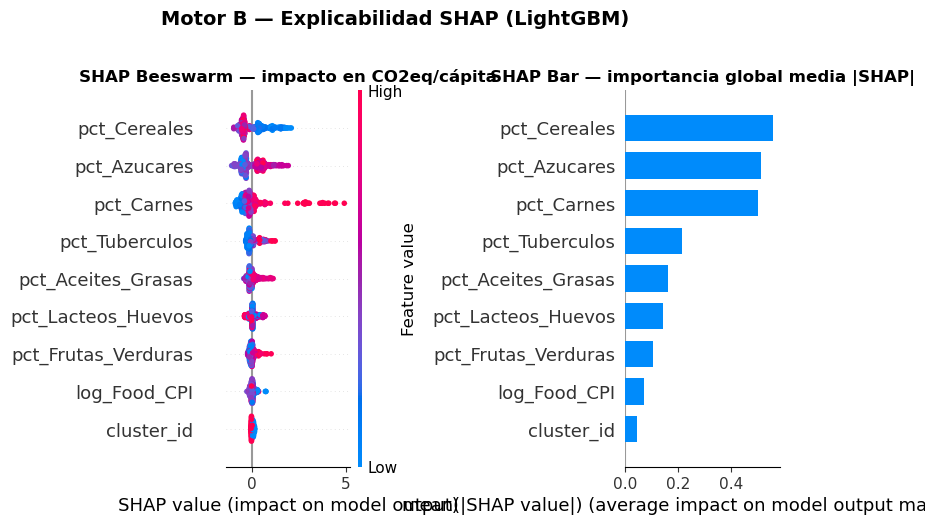

Guardado: processed/04_shap_global.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Beeswarm
plt.sca(axes[0])
shap.summary_plot(shap_values, X, plot_type='dot',
                  feature_names=FEATURES, show=False,
                  max_display=9)
axes[0].set_title('SHAP Beeswarm — impacto en CO2eq/cápita',
                  fontsize=12, fontweight='bold')

# Bar (importancia media)
plt.sca(axes[1])
shap.summary_plot(shap_values, X, plot_type='bar',
                  feature_names=FEATURES, show=False,
                  max_display=9)
axes[1].set_title('SHAP Bar — importancia global media |SHAP|',
                  fontsize=12, fontweight='bold')

plt.suptitle('Motor B — Explicabilidad SHAP (LightGBM)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../processed/04_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: processed/04_shap_global.png')

---
## Celda 12 — SHAP por clúster: ¿el efecto de Carnes varía entre tipologías?

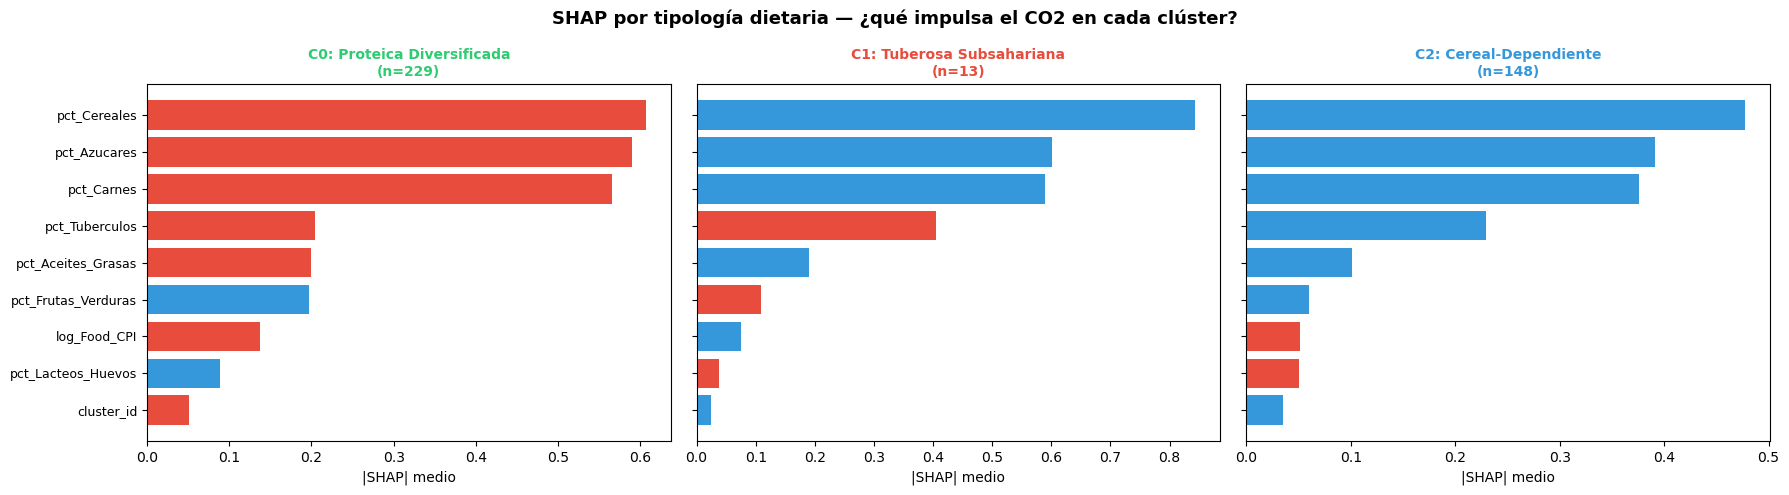

Guardado: processed/04_shap_por_cluster.png


In [12]:
# ──────────────────────────────────────────────────────────────────
# NOMBRES DE CLÚSTERES — editables en cualquier momento
# Cambia los valores de CLUSTER_NAMES y NOMBRES_MAP para renombrar.
# Los colores también son configurables en CLUSTER_COLORS.
# ──────────────────────────────────────────────────────────────────
# Separar SHAP values por clúster para detectar heterogeneidad
cluster_labels = df['cluster_id'].values
cluster_nombres = df['cluster_nombre'].values

CLUSTER_COLORS = {0: '#2ecc71', 1: '#e74c3c', 2: '#3498db'}
CLUSTER_NAMES  = {
    0: 'C0: Proteica Diversificada',
    1: 'C1: Tuberosa Subsahariana',
    2: 'C2: Cereal-Dependiente'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for cid, ax in enumerate(axes):
    mask = cluster_labels == cid
    sv_c = shap_values[mask]
    mean_abs_c = np.abs(sv_c).mean(axis=0)
    
    order = np.argsort(mean_abs_c)[::-1]
    feat_sorted = [FEATURES[i] for i in order]
    vals_sorted = mean_abs_c[order]
    signed_sorted = sv_c.mean(axis=0)[order]
    bar_colors = ['#e74c3c' if s > 0 else '#3498db' for s in signed_sorted]
    
    ax.barh(range(len(feat_sorted)), vals_sorted, color=bar_colors)
    ax.set_yticks(range(len(feat_sorted)))
    ax.set_yticklabels(feat_sorted, fontsize=9)
    ax.set_title(f'{CLUSTER_NAMES[cid]}\n(n={mask.sum()})',
                 fontsize=10, fontweight='bold',
                 color=CLUSTER_COLORS[cid])
    ax.set_xlabel('|SHAP| medio')
    ax.invert_yaxis()

plt.suptitle('SHAP por tipología dietaria — ¿qué impulsa el CO2 en cada clúster?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../processed/04_shap_por_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: processed/04_shap_por_cluster.png')

---
## Celda 13 — SHAP dependence plots: Carnes y Cereales (las dos variables clave)

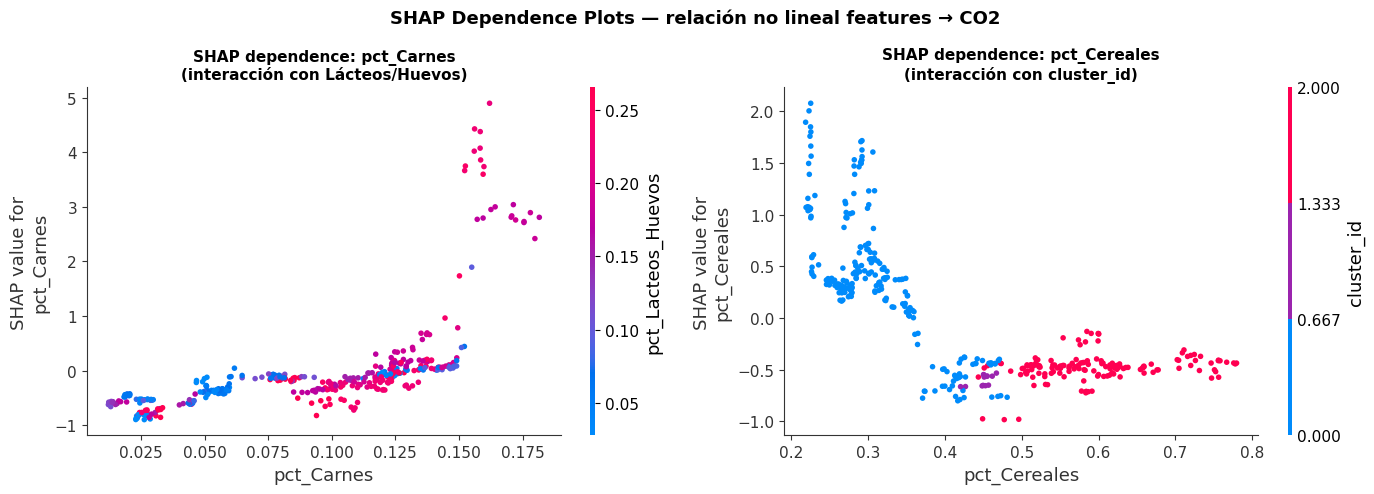

Guardado: processed/04_shap_dependence.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dependence plot: pct_Carnes → SHAP (coloreado por pct_Lacteos_Huevos)
shap.dependence_plot(
    'pct_Carnes', shap_values, X,
    interaction_index='pct_Lacteos_Huevos',
    ax=axes[0], show=False
)
axes[0].set_title('SHAP dependence: pct_Carnes\n(interacción con Lácteos/Huevos)',
                  fontsize=11, fontweight='bold')

# Dependence plot: pct_Cereales → SHAP (coloreado por cluster_id)
shap.dependence_plot(
    'pct_Cereales', shap_values, X,
    interaction_index='cluster_id',
    ax=axes[1], show=False
)
axes[1].set_title('SHAP dependence: pct_Cereales\n(interacción con cluster_id)',
                  fontsize=11, fontweight='bold')

plt.suptitle('SHAP Dependence Plots — relación no lineal features → CO2',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../processed/04_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: processed/04_shap_dependence.png')

---
## Celda 14 — Residual plot y predicciones vs observados

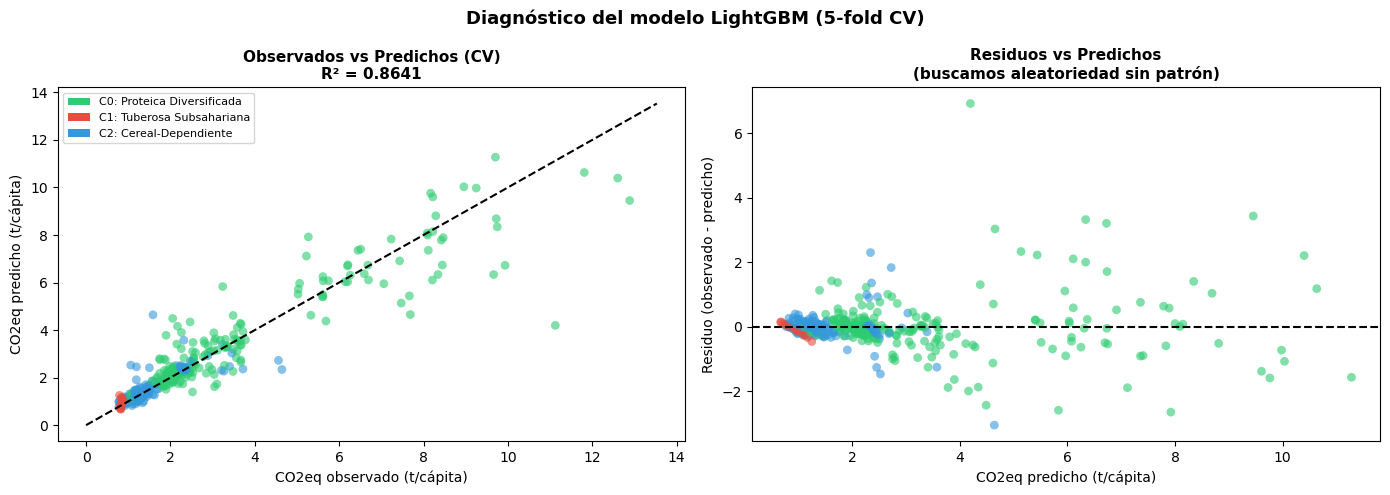


Estadísticas de residuos:
  Media: 0.0013 (esperado ~0)
  Std:   0.7876
  Max error absoluto: 6.9283
Guardado: processed/04_residuals.png


In [14]:
# Predicciones de CV (concatenar todos los folds)
from sklearn.model_selection import cross_val_predict

lgb_cv_pred = lgb.LGBMRegressor(**PARAMS_LGB)
y_pred_cv = cross_val_predict(lgb_cv_pred, X, y_abs, cv=kf)

residuals = y_abs - y_pred_cv

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Observados vs Predichos
scatter_colors = [CLUSTER_COLORS[c] for c in cluster_labels]
axes[0].scatter(y_abs, y_pred_cv, c=scatter_colors, alpha=0.6, edgecolors='none', s=40)
lim_max = max(y_abs.max(), y_pred_cv.max()) * 1.05
axes[0].plot([0, lim_max], [0, lim_max], 'k--', lw=1.5, label='Predicción perfecta')
axes[0].set_xlabel('CO2eq observado (t/cápita)')
axes[0].set_ylabel('CO2eq predicho (t/cápita)')
axes[0].set_title(f'Observados vs Predichos (CV)\nR² = {r2_test_abs:.4f}',
                  fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=CLUSTER_COLORS[i], label=CLUSTER_NAMES[i]) for i in range(3)]
axes[0].legend(handles=legend_elements, fontsize=8)

# Residuos vs Predichos
axes[1].scatter(y_pred_cv, residuals, c=scatter_colors, alpha=0.6, edgecolors='none', s=40)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('CO2eq predicho (t/cápita)')
axes[1].set_ylabel('Residuo (observado - predicho)')
axes[1].set_title('Residuos vs Predichos\n(buscamos aleatoriedad sin patrón)',
                  fontsize=11, fontweight='bold')

plt.suptitle('Diagnóstico del modelo LightGBM (5-fold CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../processed/04_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nEstadísticas de residuos:')
print(f'  Media: {residuals.mean():.4f} (esperado ~0)')
print(f'  Std:   {residuals.std():.4f}')
print(f'  Max error absoluto: {residuals.abs().max():.4f}')
print('Guardado: processed/04_residuals.png')

---
## Celda 15 — Tabla resumen de resultados (para memoria y FAQs)

In [15]:
# Tabla resumen de métricas
results_summary = pd.DataFrame({
    'Modelo': [
        'Baseline LinReg (CO2 abs)',
        'LightGBM (CO2 abs)',
        'LightGBM (CO2 intensidad)'
    ],
    'Target': [
        'CO2eq_t_per_capita',
        'CO2eq_t_per_capita',
        'CO2eq_per_Kcal'
    ],
    'R² CV (media)': [
        round(baseline_r2, 4),
        round(r2_test_abs, 4),
        round(r2_test_int, 4)
    ],
    'R² CV (std)': [
        round(cv_abs['test_r2'].std(), 4),
        round(cv_lgb_abs['test_r2'].std(), 4),
        round(cv_lgb_int['test_r2'].std(), 4)
    ],
    'MAE': [
        round(-cv_abs['test_neg_mean_absolute_error'].mean(), 4),
        round(mae_abs, 4),
        round(mae_int, 6)
    ],
    'Objetivo ≥0.4': [
        '✅' if baseline_r2 >= 0.4 else '❌',
        '✅' if r2_test_abs >= 0.4 else '❌',
        '✅' if r2_test_int >= 0.4 else '❌'
    ]
})

print('TABLA RESUMEN — Motor B')
print('=' * 75)
print(results_summary.to_string(index=False))

# SHAP top features
print('\n\nTOP FEATURES SHAP (|SHAP| medio global):')
print(shap_mean.round(4).to_string())

print('\n\nDIRECCIÓN DE EFECTOS SHAP (media con signo):')
print(shap_signed.round(4).to_string())

TABLA RESUMEN — Motor B
                   Modelo             Target  R² CV (media)  R² CV (std)      MAE Objetivo ≥0.4
Baseline LinReg (CO2 abs) CO2eq_t_per_capita         0.2915       0.1935 1.249800             ❌
       LightGBM (CO2 abs) CO2eq_t_per_capita         0.8641       0.0497 0.411200             ✅
LightGBM (CO2 intensidad)     CO2eq_per_Kcal         0.8397       0.0640 0.359969             ✅


TOP FEATURES SHAP (|SHAP| medio global):
pct_Cereales           0.5572
pct_Azucares           0.5145
pct_Carnes             0.5027
pct_Tuberculos         0.2164
pct_Aceites_Grasas     0.1617
pct_Lacteos_Huevos     0.1422
pct_Frutas_Verduras    0.1060
log_Food_CPI           0.0729
cluster_id             0.0441


DIRECCIÓN DE EFECTOS SHAP (media con signo):
pct_Lacteos_Huevos     0.0390
pct_Cereales           0.0174
cluster_id             0.0162
log_Food_CPI           0.0063
pct_Frutas_Verduras    0.0027
pct_Aceites_Grasas    -0.0005
pct_Carnes            -0.0089
pct_Tuberculos        

---
## Celda 16 — Exportar resultados a parquet

In [16]:
# Añadir predicciones CV y SHAP values al dataframe
df_out = df.copy()
df_out['log_Food_CPI']      = df['Food_CPI'].pipe(np.log).astype('float32')
df_out['CO2eq_per_Kcal']    = df_out['CO2eq_t_per_capita'] / (
                                df_out['Total_DES_Kcal'] * 365 / 1_000_000
                              ).astype('float32')
df_out['CO2_pred_cv']       = y_pred_cv.astype('float32')
df_out['CO2_residual']      = (y_abs - y_pred_cv).astype('float32')

# SHAP values como columnas
for i, feat in enumerate(FEATURES):
    df_out[f'shap_{feat}'] = shap_values[:, i].astype('float32')

print(f'Shape output: {df_out.shape}')
print(f'Columnas nuevas: log_Food_CPI, CO2eq_per_Kcal, CO2_pred_cv, CO2_residual, shap_*')
print(f'Nulos: {df_out.isnull().sum().sum()}')

df_out.to_parquet('../processed/04_model_results.parquet', index=False)
print('\n✅ Guardado: processed/04_model_results.parquet')

gc.collect()
print('Memoria liberada')

Shape output: (390, 28)
Columnas nuevas: log_Food_CPI, CO2eq_per_Kcal, CO2_pred_cv, CO2_residual, shap_*
Nulos: 0

✅ Guardado: processed/04_model_results.parquet
Memoria liberada


---
## Celda 17 — Validación final del parquet exportado

In [17]:
df_check = pd.read_parquet('../processed/04_model_results.parquet')

print('=== VALIDACIÓN 04_model_results.parquet ===')
print(f'Shape: {df_check.shape}')
print(f'Nulos: {df_check.isnull().sum().sum()}')
print(f'Columnas: {df_check.columns.tolist()}')
print()
print('Columnas SHAP:')
shap_cols = [c for c in df_check.columns if c.startswith('shap_')]
print(df_check[shap_cols].describe().round(4))
print()
print('Predicciones vs observados (muestra 5):')
print(df_check[['Area', 'Year', 'cluster_nombre',
                'CO2eq_t_per_capita', 'CO2_pred_cv', 'CO2_residual']].sample(5).to_string())

=== VALIDACIÓN 04_model_results.parquet ===
Shape: (390, 28)
Nulos: 0
Columnas: ['Area', 'Year', 'pct_Cereales', 'pct_Tuberculos', 'pct_Azucares', 'pct_Aceites_Grasas', 'pct_Carnes', 'pct_Lacteos_Huevos', 'pct_Frutas_Verduras', 'Total_DES_Kcal', 'Ratio_Proteina_AV', 'CO2eq_t_per_capita', 'Food_CPI', 'cluster_id', 'cluster_nombre', 'log_Food_CPI', 'CO2eq_per_Kcal', 'CO2_pred_cv', 'CO2_residual', 'shap_pct_Cereales', 'shap_pct_Tuberculos', 'shap_pct_Azucares', 'shap_pct_Aceites_Grasas', 'shap_pct_Carnes', 'shap_pct_Lacteos_Huevos', 'shap_pct_Frutas_Verduras', 'shap_log_Food_CPI', 'shap_cluster_id']

Columnas SHAP:
       shap_pct_Cereales  shap_pct_Tuberculos  shap_pct_Azucares  \
count           390.0000             390.0000           390.0000   
mean              0.0174              -0.0205            -0.0517   
std               0.6590               0.2851             0.5871   
min              -0.9825              -0.3512            -1.0955   
25%              -0.4879              -0

---
## Celda 18 — Resumen ejecutivo final

Para copiar directamente a la memoria y las FAQs.

In [18]:
print('=' * 60)
print('RESUMEN EJECUTIVO — MOTOR B')
print('Aguacate Team · TFM La Dieta de un País')
print('=' * 60)
print()
print(f'MÉTRICAS DE ÉXITO:')
print(f'  LightGBM R² CV = {r2_test_abs:.4f}  '
      f'({"CUMPLE" if r2_test_abs >= 0.4 else "NO CUMPLE"} objetivo ≥ 0.40)')
print(f'  Baseline LinReg R² = {baseline_r2:.4f}')
print(f'  Ganancia sobre baseline: +{r2_test_abs - baseline_r2:.4f} R²')
print()
print('TOP 3 DRIVERS DE CO2 (SHAP global):')
for feat, val in shap_mean.head(3).items():
    signo = '+' if shap_signed[feat] > 0 else '-'
    print(f'  {feat}: |SHAP|={val:.4f} (efecto {signo})')
print()
print('COHERENCIA CON TEORÍA IPCC:')
carne_shap = shap_signed.get('pct_Carnes', 0)
cereal_shap = shap_signed.get('pct_Cereales', 0)
print(f'  pct_Carnes   SHAP={carne_shap:.4f} → '
      f'{"✅ positivo (más carne = más CO2)" if carne_shap > 0 else "⚠️ revisar signo"}')
print(f'  pct_Cereales SHAP={cereal_shap:.4f} → '
      f'{"✅ negativo (cereal ancla CO2 bajo)" if cereal_shap < 0 else "⚠️ revisar signo"}')
print()
print(f'OUTPUT: processed/04_model_results.parquet')
print(f'        {df_check.shape[0]} filas × {df_check.shape[1]} columnas')
print(f'        incluye predicciones CV + 9 columnas SHAP')

RESUMEN EJECUTIVO — MOTOR B
Aguacate Team · TFM La Dieta de un País

MÉTRICAS DE ÉXITO:
  LightGBM R² CV = 0.8641  (CUMPLE objetivo ≥ 0.40)
  Baseline LinReg R² = 0.2915
  Ganancia sobre baseline: +0.5726 R²

TOP 3 DRIVERS DE CO2 (SHAP global):
  pct_Cereales: |SHAP|=0.5572 (efecto +)
  pct_Azucares: |SHAP|=0.5145 (efecto -)
  pct_Carnes: |SHAP|=0.5027 (efecto -)

COHERENCIA CON TEORÍA IPCC:
  pct_Carnes   SHAP=-0.0089 → ⚠️ revisar signo
  pct_Cereales SHAP=0.0174 → ⚠️ revisar signo

OUTPUT: processed/04_model_results.parquet
        390 filas × 28 columnas
        incluye predicciones CV + 9 columnas SHAP


In [19]:
# ── EXPORTAR MODELO ─────────────────────────────────────────────
# lgb_final está entrenado sobre el dataset completo (390 obs)
# Se guarda para que el dashboard y el Motor C puedan cargarlo
import joblib
joblib.dump(lgb_final, '../processed/lgb_final.pkl')
print('Modelo exportado: processed/lgb_final.pkl')
print(f'Features: {FEATURES}')
print(f'Target: CO2eq_t_per_capita')

Modelo exportado: processed/lgb_final.pkl
Features: ['pct_Cereales', 'pct_Tuberculos', 'pct_Azucares', 'pct_Aceites_Grasas', 'pct_Carnes', 'pct_Lacteos_Huevos', 'pct_Frutas_Verduras', 'log_Food_CPI', 'cluster_id']
Target: CO2eq_t_per_capita
